# Notebook 8 — Fronteira Eficiente: Média-Variância e Média-CVaR

**TCC — Pedro Augusto Pinheiro Reis · Ciências Contábeis · UFG**

Este notebook calcula a fronteira eficiente clássica (média-variância de Markowitz) e a fronteira da teoria pós-moderna (média-CVaR) para o universo investível da B3. Também gera a nuvem de carteiras simuladas por Monte Carlo e exporta as carteiras canônicas e imagens consolidadas para tabulação e escrita do TCC.

## 1. Importações e Configurações

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.config_loader import carregar_parametros
from utils.fronteira import (
    ledoit_wolf,
    min_var,
    max_sharpe,
    min_cvar,
    cvar_diario,
    port_ret,
    port_vol,
    CVXPY_OK
)

# Carrega configurações centrais
cfg = carregar_parametros()
SEED = cfg.get("SEED", 42)
N_MONTECARLO = cfg.get("N_MONTECARLO", 50000)
N_PONTOS_FRONT = cfg.get("N_PONTOS_FRONT", 60)
ATIVOS_NUVEM = cfg.get("ATIVOS_NUVEM", 10)
ALPHA = cfg.get("ALPHA_PMPT", 0.95)
TETO_PESO = cfg.get("TETO_PESO", 0.10)
DIRICHLET_ALPHA = cfg.get("DIRICHLET_ALPHA", 0.30)
TRADING_DAYS = 252

np.random.seed(SEED)

project_root = Path.cwd().parent.parent
DIR_RETORNOS = project_root / "data" / "Retornos"
OUTPUT_DIR = project_root / "data" / "Estrategias"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Configurações carregadas. CVXPY disponível: {CVXPY_OK}")

✓ Configurações carregadas. CVXPY disponível: False


## 2. Leitura dos Retornos e Taxa de Juros

In [2]:
def _ler(nome, col=None):
    pq = DIR_RETORNOS / f"{nome}.parquet"
    csv = DIR_RETORNOS / f"{nome}.csv"
    df = pd.read_parquet(pq) if pq.exists() else pd.read_csv(csv, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df[col] if col else df

ret = _ler("retornos_simples_saneado").sort_index()
try:
    rf_d = _ler("rf_diario", "cdi_diario").reindex(ret.index).dropna()
    rf_anual = float(rf_d.mean() * TRADING_DAYS)
except Exception:
    rf_anual = 0.10

N = ret.shape[1]
print(f"Retornos: {ret.shape[0]} pregões × {N} ativos | rf anualizado usado = {rf_anual:.4f}")

Retornos: 3966 pregões × 118 ativos | rf anualizado usado = 0.0929


## 3. Estimação de Parâmetros (Média e Covariância via Ledoit-Wolf)

In [3]:
R = ret.values
mu = R.mean(axis=0) * TRADING_DAYS
Sig = ledoit_wolf(R) * TRADING_DAYS

print(f"μ média anualizada: {mu.mean():.4f} [{mu.min():.3f}, {mu.max():.3f}]")
print(f"Vol média anualizada dos ativos: {np.sqrt(np.diag(Sig)).mean():.4f}")

μ média anualizada: 0.0512 [-1.174, 0.289]
Vol média anualizada dos ativos: 0.3980


## 4. Nuvem Monte Carlo de Oportunidades Viáveis

In [4]:
rng = np.random.default_rng(SEED)
# Seleciona subconjunto de ativos de forma uniforme em termos de volatilidade para visualização
ordem = np.argsort(np.diag(Sig))
idx_sub = ordem[np.linspace(0, N-1, ATIVOS_NUVEM).astype(int)]
mu_s = mu[idx_sub]
Sig_s = Sig[np.ix_(idx_sub, idx_sub)]

W = rng.dirichlet(np.full(ATIVOS_NUVEM, DIRICHLET_ALPHA), size=N_MONTECARLO)
mc_ret = W @ mu_s
mc_vol = np.sqrt(np.einsum('ij,jk,ik->i', W, Sig_s, W))
mc_sharpe = (mc_ret - rf_anual) / mc_vol

print(f"Nuvem: {N_MONTECARLO} carteiras simuladas sobre {ATIVOS_NUVEM} ativos.")

Nuvem: 50000 carteiras simuladas sobre 10 ativos.


## 5. Fronteira Média-Variância e Carteiras Canônicas

In [5]:
w_mvp = min_var(Sig, mu)
w_tan = max_sharpe(mu, Sig, rf_anual)
w_tan10 = max_sharpe(mu, Sig, rf_anual, TETO_PESO)

alvos = np.linspace(port_ret(w_mvp, mu), mu.max() * 0.98, N_PONTOS_FRONT)
fmv = []
for a in alvos:
    w = min_var(Sig, mu, ret_alvo=a)
    if abs(port_ret(w, mu) - a) < 1e-3:
        fmv.append((port_vol(w, Sig), port_ret(w, mu)))
fmv = np.array(fmv)

print(f"Fronteira MV: {len(fmv)} pontos obtidos.")
print(f"MVP:      vol={port_vol(w_mvp, Sig):.4f} ret={port_ret(w_mvp, mu):.4f}")
print(f"Tangente: vol={port_vol(w_tan, Sig):.4f} ret={port_ret(w_tan, mu):.4f}")
print(f"Tangente (Cap 10%): vol={port_vol(w_tan10, Sig):.4f} ret={port_ret(w_tan10, mu):.4f}")

Fronteira MV: 60 pontos obtidos.
MVP:      vol=0.1191 ret=0.1238
Tangente: vol=0.1773 ret=0.2497
Tangente (Cap 10%): vol=0.1564 ret=0.2243


## 6. Fronteira Média-CVaR (PMPT)

In [6]:
fcvar = []
w_mincvar = None
if CVXPY_OK:
    w_mincvar = min_cvar(R, mu, ALPHA)
    if w_mincvar is not None:
        w_mincvar = w_mincvar / w_mincvar.sum()
        # Varre retornos-alvo para traçar a fronteira média-CVaR
        for a in np.linspace(port_ret(w_mincvar, mu), mu.max() * 0.95, max(20, N_PONTOS_FRONT // 2)):
            w = min_cvar(R, mu, ALPHA, ret_alvo=a)
            if w is not None and abs(w.sum() - 1.0) < 1e-3:
                fcvar.append((cvar_diario(w / w.sum(), R, ALPHA), port_ret(w / w.sum(), mu)))
        fcvar = np.array(fcvar)
        print(f"Fronteira média-CVaR: {len(fcvar)} pontos obtidos.")
        print(f"Min-CVaR: CVaR_diário={cvar_diario(w_mincvar, R, ALPHA):.5f} ret={port_ret(w_mincvar, mu):.4f}")
else:
    print("[AVISO] cvxpy ou solvers ausentes. Fronteira CVaR pulada.")

[AVISO] cvxpy ou solvers ausentes. Fronteira CVaR pulada.


## 7. Gráficos Consolidados (Espaço MPT e PMPT)

[OK] Imagens salvas com sucesso em: C:\VSCodeWorkspace\1_TCC_Final\data\Estrategias


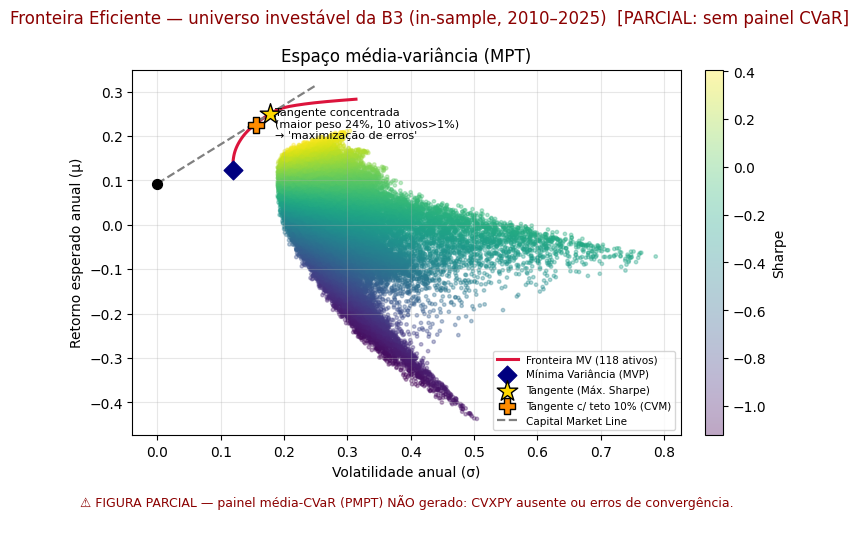

In [7]:
n_panels = 2 if (CVXPY_OK and len(fcvar) > 0) else 1
fig, axs = plt.subplots(1, n_panels, figsize=((13, 5.2) if n_panels == 2 else (7.5, 5.5)))
axes = np.atleast_1d(axs)
ax0 = axes[0]

sc = ax0.scatter(mc_vol, mc_ret, c=mc_sharpe, s=6, alpha=0.35, cmap="viridis", rasterized=True)
ax0.plot(fmv[:, 0], fmv[:, 1], "-", color="crimson", lw=2.2, label="Fronteira MV (118 ativos)")
ax0.scatter([port_vol(w_mvp, Sig)], [port_ret(w_mvp, mu)], marker="D", s=90, color="navy", zorder=5, label="Mínima Variância (MVP)")
ax0.scatter([port_vol(w_tan, Sig)], [port_ret(w_tan, mu)], marker="*", s=240, color="gold", edgecolor="black", zorder=5, label="Tangente (Máx. Sharpe)")
ax0.scatter([port_vol(w_tan10, Sig)], [port_ret(w_tan10, mu)], marker="P", s=120, color="darkorange", edgecolor="black", zorder=5, label="Tangente c/ teto 10% (CVM)")

# Plota a Capital Market Line (CML)
x_cml = np.linspace(0, port_vol(w_tan, Sig) * 1.4, 50)
sh_t = (port_ret(w_tan, mu) - rf_anual) / port_vol(w_tan, Sig)
ax0.plot(x_cml, rf_anual + sh_t * x_cml, "--", color="gray", lw=1.6, label="Capital Market Line")
ax0.scatter([0], [rf_anual], marker="o", s=50, color="black", zorder=5)

ax0.annotate(f"Tangente concentrada\n(maior peso {w_tan.max():.0%}, {(w_tan>0.01).sum()} ativos>1%)\n→ 'maximização de erros'",
             xy=(port_vol(w_tan, Sig), port_ret(w_tan, mu)),
             xytext=(port_vol(w_tan, Sig) * 1.05, port_ret(w_tan, mu) * 0.78),
             fontsize=8, arrowprops=dict(arrowstyle="->", color="black"))

ax0.set_xlabel("Volatilidade anual (σ)")
ax0.set_ylabel("Retorno esperado anual (μ)")
ax0.set_title("Espaço média-variância (MPT)")
ax0.legend(fontsize=7.5, loc="lower right")
ax0.grid(alpha=0.3)
fig.colorbar(sc, ax=ax0, label="Sharpe", fraction=0.046, pad=0.04)

if CVXPY_OK and len(fcvar) > 0:
    ax1 = axes[1]
    ax1.plot(fcvar[:, 0], fcvar[:, 1], "-o", color="teal", ms=3, lw=2, label="Fronteira média-CVaR (118 ativos)")
    ax1.scatter([cvar_diario(w_mincvar, R, ALPHA)], [port_ret(w_mincvar, mu)], marker="D", s=90, color="purple", zorder=5, label="Mínimo CVaR")
    ax1.set_xlabel(f"CVaR diário (α={ALPHA:.0%})")
    ax1.set_ylabel("Retorno esperado anual (μ)")
    ax1.set_title("Espaço média-CVaR (PMPT)")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    FIGURA_COMPLETA = True
else:
    FIGURA_COMPLETA = False
    motivo = "CVXPY ausente ou erros de convergência"
    ax0.text(0.5, -0.16,
             f"⚠ FIGURA PARCIAL — painel média-CVaR (PMPT) NÃO gerado: {motivo}.\n",
             transform=ax0.transAxes, ha="center", va="top", fontsize=9, color="darkred")

_titulo = "Fronteira Eficiente — universo investável da B3 (in-sample, 2010–2025)"
if not FIGURA_COMPLETA:
    _titulo += "  [PARCIAL: sem painel CVaR]"
fig.suptitle(_titulo, fontsize=12, color=("black" if FIGURA_COMPLETA else "darkred"))
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "fronteira_eficiente.png", dpi=150, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "fronteira_eficiente.svg", bbox_inches="tight")
print("[OK] Imagens salvas com sucesso em:", OUTPUT_DIR)
plt.show()

## 8. Exportação dos Resultados (CSV)

In [8]:
pd.DataFrame(fmv, columns=["vol", "ret"]).to_csv(OUTPUT_DIR / "fronteira_mv_pontos.csv", index=False)
if CVXPY_OK and len(fcvar) > 0:
    pd.DataFrame(fcvar, columns=["cvar_diario", "ret"]).to_csv(OUTPUT_DIR / "fronteira_cvar_pontos.csv", index=False)

canon = {"MVP": w_mvp, "Tangente": w_tan, "Tangente_c10": w_tan10}
if CVXPY_OK and w_mincvar is not None:
    canon["MinCVaR"] = w_mincvar

linhas = []
for nome, w in canon.items():
    linhas.append({
        "carteira": nome,
        "ret_anual": port_ret(w, mu),
        "vol_anual": port_vol(w, Sig),
        "sharpe": (port_ret(w, mu) - rf_anual) / port_vol(w, Sig),
        "maior_peso": float(w.max()),
        "n_ativos_>1pct": int((w > 0.01).sum())
    })

pd.DataFrame(linhas).to_csv(OUTPUT_DIR / "carteiras_canonicas.csv", index=False, float_format="%.6f")
print("✓ Resultados salvos com sucesso em:", OUTPUT_DIR)

✓ Resultados salvos com sucesso em: C:\VSCodeWorkspace\1_TCC_Final\data\Estrategias
